Name - Nikhil Nikam

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
pa=pd.read_csv("Property_Price_Train.csv")
pa = pa.sample(frac = 1)

In [3]:
pa.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1174,1175,70,RL,80.0,16560,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2006,WD,Normal,239000
1314,1315,20,RL,60.0,8190,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2007,WD,Normal,119000
864,865,20,FV,72.0,8640,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2008,New,Partial,250580
1363,1364,60,RL,73.0,8499,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2007,New,Partial,156932
1133,1134,60,RL,80.0,9828,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,239500


In [4]:
pa.shape

(1460, 81)

In [5]:
pa = pa.drop(['Id'], axis = 1)

In [6]:
pa.isnull().sum()[pa.isnull().sum() >0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [7]:
pa.fillna(pa.median(numeric_only=True), inplace=True)
num_cols = pa.select_dtypes(include=['int64', 'float64']).columns
cat_cols = pa.select_dtypes(include=['object']).columns
num_cols = pa.select_dtypes(include=['int64', 'float64']).columns
cat_cols = pa.select_dtypes(include=['object']).columns
pa[num_cols] = pa[num_cols].fillna(pa[num_cols].median())

for col in cat_cols:
    pa[col] = pa[col].fillna(pa[col].mode()[0])

pa.fillna({
    col: pa[col].median() if pa[col].dtype != 'object' else pa[col].mode()[0]
    for col in pa.columns
}, inplace=True)

In [8]:
'''pa.fillna(pa.median(numeric_only=True), inplace=True)
pa= pa.drop(['Lane_Type','Fireplace_Quality','Pool_Quality','Fence_Quality','Miscellaneous_Feature'],axis=1)


pa.Basement_Height.fillna('TA',inplace=True)
pa.Exposure_Level.fillna('No',inplace=True)
pa.BsmtFinType1.fillna('Unf',inplace=True)
pa.BsmtFinType2.fillna('Unf',inplace=True)
pa.Electrical_System.fillna('SBrkr',inplace=True)
pa.Garage.fillna('Attchd',inplace=True)
pa.Garage_Finish_Year.fillna('Unf',inplace=True)
pa.Garage_Quality.fillna('TA',inplace=True)
pa.Garage_Condition.value_counts()
pa.Basement_Condition.fillna('TA',inplace=True)
pa.Garage_Condition=pa.Garage_Condition.fillna('TA')
pa.Brick_Veneer_Type=pa.Brick_Veneer_Type.fillna('None')
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

pa[pa.select_dtypes(include=['object']).columns]  = pa[pa.select_dtypes(include=['object']).columns].apply(le.fit_transform) '''

"pa.fillna(pa.median(numeric_only=True), inplace=True)\npa= pa.drop(['Lane_Type','Fireplace_Quality','Pool_Quality','Fence_Quality','Miscellaneous_Feature'],axis=1)\n\n\npa.Basement_Height.fillna('TA',inplace=True)\npa.Exposure_Level.fillna('No',inplace=True)\npa.BsmtFinType1.fillna('Unf',inplace=True)\npa.BsmtFinType2.fillna('Unf',inplace=True)\npa.Electrical_System.fillna('SBrkr',inplace=True)\npa.Garage.fillna('Attchd',inplace=True)\npa.Garage_Finish_Year.fillna('Unf',inplace=True)\npa.Garage_Quality.fillna('TA',inplace=True)\npa.Garage_Condition.value_counts()\npa.Basement_Condition.fillna('TA',inplace=True)\npa.Garage_Condition=pa.Garage_Condition.fillna('TA')\npa.Brick_Veneer_Type=pa.Brick_Veneer_Type.fillna('None')\nfrom sklearn.preprocessing import LabelEncoder\nle = LabelEncoder()\n\npa[pa.select_dtypes(include=['object']).columns]  = pa[pa.select_dtypes(include=['object']).columns].apply(le.fit_transform) "

In [9]:
pa1 = pa

In [10]:
pa1.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1174,70,RL,80.0,16560,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,0,Gd,MnPrv,Shed,0,7,2006,WD,Normal,239000
1314,20,RL,60.0,8190,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,Gd,MnPrv,Shed,0,10,2007,WD,Normal,119000
864,20,FV,72.0,8640,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,Gd,MnPrv,Shed,0,5,2008,New,Partial,250580
1363,60,RL,73.0,8499,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,0,Gd,MnPrv,Shed,0,3,2007,New,Partial,156932
1133,60,RL,80.0,9828,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,0,Gd,MnPrv,Shed,0,6,2009,WD,Normal,239500


In [11]:
pa1.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

In [12]:
pa1 = pa1.drop('Sale_Price', axis=1, errors='ignore')

In [13]:
X = pa.drop('SalePrice', axis=1)
y = pa['SalePrice']


In [14]:
print('SalePrice' in pa1.columns)

True


In [15]:
if 'SalePrice' in pa1.columns:
    pa1 = pa1.drop('SalePrice', axis=1)

In [16]:
X = pa.drop('SalePrice', axis=1)
y = pa['SalePrice']

In [17]:
pa1.shape

(1460, 79)

In [18]:
##before transfer pca standarize the data

In [19]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

In [ ]:
scaled_pa1=scaler.fit_transform(pa1)

In [22]:
pca = PCA()

In [23]:
###there is no one on one mapping between pcs componenet

In [24]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler=StandardScaler()
scaled_pa1=scaler.fit_transform(pa1)

In [ ]:
x_pca1=pca.fit_transform(scaled_pa1)
##pca transform has been done:
x_pca1.shape

In [ ]:
pca.explained_variance_ratio_

In [ ]:
l1=list(pca.explained_variance_ratio_)

In [ ]:
np.sum(l1[0:55])

In [ ]:
##let's build our linear rigresion model
##where my x cols?


In [ ]:
df=pd.DataFrame(x_pca1)

In [ ]:
df = df.iloc[: , 0:55]

In [29]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()

In [ ]:
df.shape

In [ ]:
linreg.fit(df, pa.SalePrice)

In [ ]:
linreg.score(df,pa.SalePrice)

In [ ]:
##there is no one and one maping between pcs and original components.

In [ ]:
np.round(df.corr(), 4)

In [33]:
##35*37+12*15+16*18+14

In [34]:
##cosine simalarity

In [35]:
A = [35 , 12 , 16 , 14]
B = [ 37 , 15 , 18 , 23]##  
C = [33 , 9 , 16  , 20]

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

In [37]:
cosine_similarity(  [A] ,  [ B])

array([[0.98772058]])

In [38]:
cosine_similarity(  [A] ,  [ C])

array([[0.98656523]])

In [39]:
##Levisnten distance--------> data is in test format

In [40]:
import pandas as pd
import numpy as np


In [41]:
ct = pd.read_csv("mushrooms.csv")

In [42]:
ct.head()

,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [43]:
ct.isnull().sum()

type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64

In [44]:
ct = pd.get_dummies(ct, drop_first=True)

In [45]:
pa.isnull().sum()[pa.isnull().sum() >0]

Series([], dtype: int64)

In [46]:
ct1 = ct

In [ ]:
ct1 =ct1.drop(['habitat'], axis = 1)

In [48]:
ct1.head()

,type_p,cap_shape_c,cap_shape_f,cap_shape_k,cap_shape_s,cap_shape_x,cap_surface_g,cap_surface_s,cap_surface_y,cap_color_c,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,True,False,False,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,False,True,False,True,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
3,True,False,False,False,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,False,True,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


In [49]:
ct1.shape

(8124, 96)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [51]:
scaler = StandardScaler()

In [53]:
scaled_ct1 = scaler.fit_transform(ct1)

In [52]:
pca = PCA()

In [54]:
x_pca1 = pca.fit_transform(scaled_ct1)

In [55]:
x_pca1.shape

(8124, 96)

In [56]:
pca.explained_variance_ratio_

array([9.90652491e-02, 7.17348258e-02, 6.03853714e-02, 5.63967880e-02,
       4.99970646e-02, 4.54434987e-02, 3.51747069e-02, 3.31493402e-02,
       2.53187500e-02, 2.44649011e-02, 2.19077033e-02, 2.05642420e-02,
       1.97983377e-02, 1.63236090e-02, 1.58175824e-02, 1.43220066e-02,
       1.37766279e-02, 1.35780555e-02, 1.28418952e-02, 1.26267880e-02,
       1.23789306e-02, 1.17581812e-02, 1.15314431e-02, 1.13652831e-02,
       1.12115792e-02, 1.08593938e-02, 1.06159135e-02, 1.05533747e-02,
       1.04785785e-02, 1.04372225e-02, 9.86292182e-03, 9.70391579e-03,
       9.59404126e-03, 9.28805963e-03, 9.02290417e-03, 8.89228718e-03,
       8.59680808e-03, 8.56187362e-03, 8.35346440e-03, 7.82962604e-03,
       7.53046623e-03, 7.46860811e-03, 7.13661602e-03, 6.79060014e-03,
       6.57538006e-03, 6.50560744e-03, 6.26126017e-03, 6.13970812e-03,
       5.65676291e-03, 5.45124865e-03, 5.26527802e-03, 5.20988633e-03,
       5.17755082e-03, 4.97946996e-03, 4.78124455e-03, 4.71224463e-03,
      

In [57]:
l1=list(pca.explained_variance_ratio_)

In [58]:
np.sum(l1[0:20])

np.float64(0.6626873435391305)

In [59]:
## lets build the linear regression model and predict sales price
##where is my x cols?


In [60]:
df = pd.DataFrame(x_pca1)

In [61]:
df = df.iloc[:, 0:55]

In [63]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()

In [64]:
df.shape

(8124, 55)

In [ ]:
linreg.fit(df,ct.habitat)

In [66]:
np.round(df.corr() , 4)

,0,1,2,3,4,5,6,7,8,9,...,45,46,47,48,49,50,51,52,53,54
0,1.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,...,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0
1,0.0,1.0,-0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0
2,-0.0,-0.0,1.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0
3,0.0,-0.0,0.0,1.0,0.0,0.0,-0.0,0.0,-0.0,0.0,...,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0
4,-0.0,0.0,0.0,0.0,1.0,0.0,-0.0,-0.0,-0.0,0.0,...,0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.0
5,-0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.0,...,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0
6,0.0,-0.0,0.0,-0.0,-0.0,0.0,1.0,-0.0,-0.0,0.0,...,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0
7,0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,1.0,0.0,-0.0,...,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0
8,0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,1.0,0.0,...,-0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
9,-0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,1.0,...,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0,-0.0


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

%matplotlib inline

In [68]:
pa = pd.read_csv("Property_Price_Train.csv")
pa = pa.sample(frac=1, random_state=42).reset_index(drop=True)
print("Shape:", pa.shape)
pa.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,893,20,RL,70.0,8414,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2006,WD,Normal,154500
1,1106,60,RL,98.0,12256,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,325000
2,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,115000
3,523,50,RM,50.0,5000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,10,2006,WD,Normal,159000
4,1037,20,RL,89.0,12898,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,315500


In [69]:
pa = pa.drop(columns=['Id'])
pa.shape

(1460, 80)

In [70]:
missing = pa.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [71]:
num_cols = pa.select_dtypes(include=['int64', 'float64']).columns
cat_cols = pa.select_dtypes(include=['object']).columns

pa[num_cols] = pa[num_cols].fillna(pa[num_cols].median())

for col in cat_cols:
    pa[col] = pa[col].fillna(pa[col].mode()[0])

print("Remaining nulls:", pa.isnull().sum().sum())

Remaining nulls: 0


In [72]:
le = LabelEncoder()
for col in cat_cols:
    pa[col] = le.fit_transform(pa[col].astype(str))

pa.dtypes.value_counts()

int64      77
float64     3
Name: count, dtype: int64

In [73]:
X = pa.drop(columns=['SalePrice'])
y = pa['SalePrice']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 79)
y shape: (1460,)


In [75]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled shape:", X_scaled.shape)

Scaled shape: (1460, 79)


In [76]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print("PCA output shape:", X_pca.shape)

PCA output shape: (1460, 79)


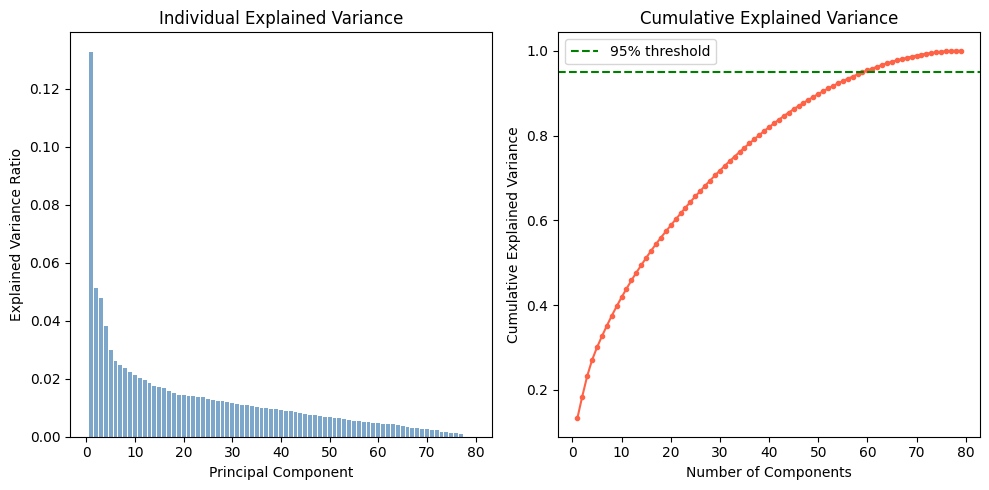

In [77]:
evr = pca.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(evr) + 1), evr, alpha=0.7, color='steelblue')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Individual Explained Variance")

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_evr) + 1), cumulative_evr, marker='o', markersize=3, color='tomato')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()

plt.tight_layout()
plt.show()

In [78]:
n_components_95 = np.argmax(cumulative_evr >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")
print(f"Variance explained by first 55 components: {np.sum(evr[:55]):.4f}")

Components needed for 95% variance: 60
Variance explained by first 55 components: 0.9283


In [79]:
df_pca = pd.DataFrame(X_pca).iloc[:, 0:55]
print("Feature matrix shape:", df_pca.shape)

linreg = LinearRegression()
linreg.fit(df_pca, y)

score = linreg.score(df_pca, y)
print(f"\nLinear Regression R² Score (train): {score:.4f}")

Feature matrix shape: (1460, 55)

Linear Regression R² Score (train): 0.8420


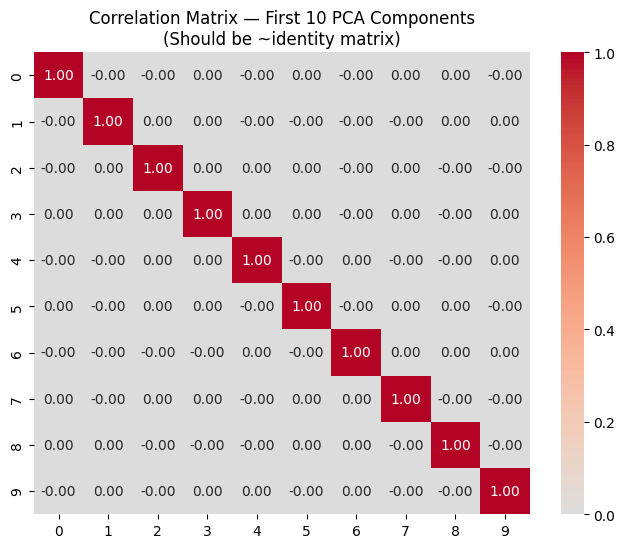

In [80]:
corr_sample = np.round(df_pca.iloc[:, :10].corr(), 4)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_sample, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — First 10 PCA Components\n(Should be ~identity matrix)")
plt.show()

In [81]:
from sklearn.metrics.pairwise import cosine_similarity

A = [35, 12, 16, 14]
B = [37, 15, 18, 23]
C = [33,  9, 16, 20]

sim_AB = cosine_similarity([A], [B])[0][0]
sim_AC = cosine_similarity([A], [C])[0][0]

print(f"Cosine Similarity A vs B: {sim_AB:.4f}")
print(f"Cosine Similarity A vs C: {sim_AC:.4f}")
print(f"\nA is more similar to {'B' if sim_AB > sim_AC else 'C'}")

Cosine Similarity A vs B: 0.9877
Cosine Similarity A vs C: 0.9866

A is more similar to B


In [82]:
ct = pd.read_csv("mushrooms.csv")
print("Shape:", ct.shape)
ct.head()

Shape: (8124, 23)


,type,cap_shape,cap_surface,cap_color,bruises,odor,gill_attachment,gill_spacing,gill_size,gill_color,...,stalk_surface_below_ring,stalk_color_above_ring,stalk_color_below_ring,veil_type,veil_color,ring_number,ring_type,spore_print_color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [83]:
print("Missing values per column:")
print(ct.isnull().sum())

Missing values per column:
type                        0
cap_shape                   0
cap_surface                 0
cap_color                   0
bruises                     0
odor                        0
gill_attachment             0
gill_spacing                0
gill_size                   0
gill_color                  0
stalk_shape                 0
stalk_root                  0
stalk_surface_above_ring    0
stalk_surface_below_ring    0
stalk_color_above_ring      0
stalk_color_below_ring      0
veil_type                   0
veil_color                  0
ring_number                 0
ring_type                   0
spore_print_color           0
population                  0
habitat                     0
dtype: int64


In [85]:
# Save target before encoding
y_mushroom = ct['type'].copy()

# Encode features (all categorical columns except 'type')
ct_encoded = pd.get_dummies(ct.drop(columns=['type']), drop_first=True)
print("Encoded feature shape:", ct_encoded.shape)
ct_encoded.head()

Encoded feature shape: (8124, 95)


,cap_shape_c,cap_shape_f,cap_shape_k,cap_shape_s,cap_shape_x,cap_surface_g,cap_surface_s,cap_surface_y,cap_color_c,cap_color_e,...,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,False,False,False,False,True,False,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
1,False,False,False,False,True,False,True,False,False,False,...,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
4,False,False,False,False,True,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [86]:
scaler_ct = StandardScaler()
scaled_ct = scaler_ct.fit_transform(ct_encoded)
print("Scaled shape:", scaled_ct.shape)

Scaled shape: (8124, 95)


In [87]:
pca_ct = PCA()
x_pca_ct = pca_ct.fit_transform(scaled_ct)
print("PCA output shape:", x_pca_ct.shape)

PCA output shape: (8124, 95)


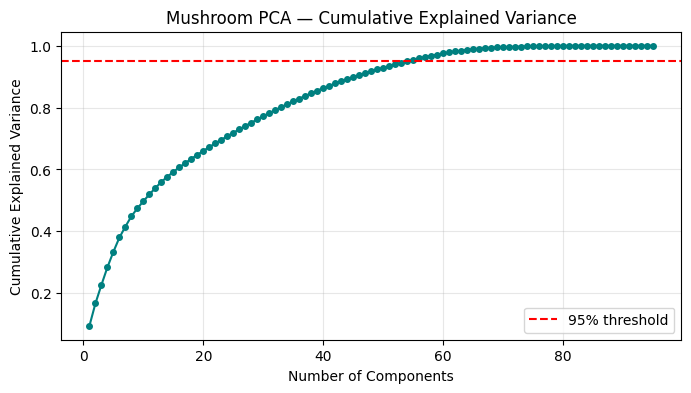

Components needed for 95% variance: 55
Variance explained by first 20 components: 0.6600


In [88]:
evr_ct = pca_ct.explained_variance_ratio_
cumulative_evr_ct = np.cumsum(evr_ct)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_evr_ct) + 1), cumulative_evr_ct, marker='o', markersize=4, color='teal')
plt.axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Mushroom PCA — Cumulative Explained Variance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

n_comp_95 = np.argmax(cumulative_evr_ct >= 0.95) + 1
print(f"Components needed for 95% variance: {n_comp_95}")
print(f"Variance explained by first 20 components: {np.sum(evr_ct[:20]):.4f}")

In [89]:
from sklearn.linear_model import LogisticRegression

# Use top 20 components (covers ~66% variance; mushrooms dataset is highly non-linear)
df_pca_ct = pd.DataFrame(x_pca_ct).iloc[:, 0:20]
print("Feature matrix shape:", df_pca_ct.shape)

# Encode target: 'e' = edible, 'p' = poisonous
le_ct = LabelEncoder()
y_encoded = le_ct.fit_transform(y_mushroom)
print("Classes:", le_ct.classes_)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(df_pca_ct, y_encoded)

score_ct = logreg.score(df_pca_ct, y_encoded)
print(f"\nLogistic Regression Accuracy (train): {score_ct:.4f}")

Feature matrix shape: (8124, 20)
Classes: ['e' 'p']

Logistic Regression Accuracy (train): 0.9996


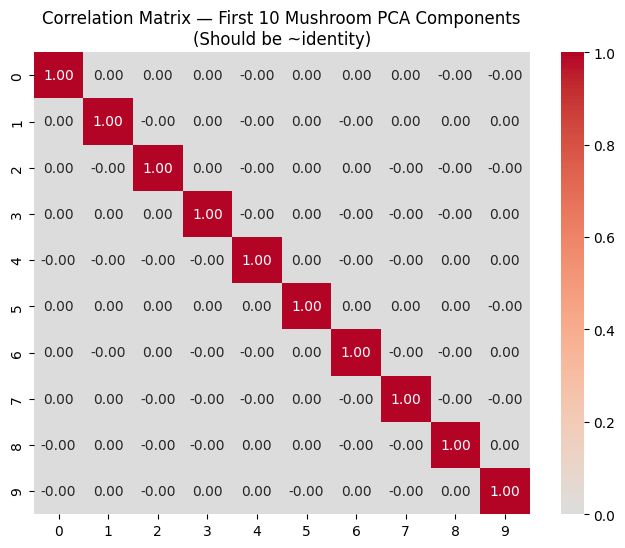

In [90]:
corr_ct = np.round(pd.DataFrame(x_pca_ct).iloc[:, :10].corr(), 4)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_ct, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — First 10 Mushroom PCA Components\n(Should be ~identity)")
plt.show()